# SABR Synthetic IV Surfaces

Generate synthetic SABR implied-volatility surfaces on the canonical grid and visualize them.

This notebook is intended for experimentation before real options-chain data integration.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

from implied_volatility_diffusion.synthetic.sabr import (
    implied_vol_surface_for_params,
    implied_vol_surfaces_lhs,
    lhs_sabr_params,
    plot_sabr_smiles,
    plot_sabr_surface,
)

In [6]:
REPO_ROOT = Path("..").resolve()
CFG_PATH = REPO_ROOT / "config" / "sabr_iv_surface.yaml"

with CFG_PATH.open("r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

cfg

{'market': {'spot': 100.0, 'dividend_yield': 0.0, 'r': 0.03},
 'sabr': {'beta': 0.5},
 'sabr_ranges': {'alpha': [0.05, 0.45],
  'rho': [-0.85, 0.85],
  'nu': [0.05, 0.9]},
 'grid': {'moneyness': {'start_point': 0.6, 'step': 0.1, 'end_point': 1.4},
  'tau': {'start_point': 0.05, 'step': 0.05, 'end_point': 2.0}},
 'lhs': {'n_samples': 32,
  'seed': 7,
  'n_batches': 1,
  'seed_stride': 10000,
  'log_uniform': ['alpha', 'nu']},
 'sequential_ivs': {'n_steps': 8,
  'dt': 0.003968253968253968,
  'path_seed_stride': 100000},
 'arbitrage_guard': {'policy': 'repair',
  'tol': 1e-08,
  'repair_before_filter': True},
 'plot_surface': {'zlim': [0.05, 0.8],
  'elev': 22,
  'azim': -125,
  'cmap': 'turbo'}}

params (alpha, rho, nu): [0.339254 0.001228 0.158197]
surface shape: (9, 40)


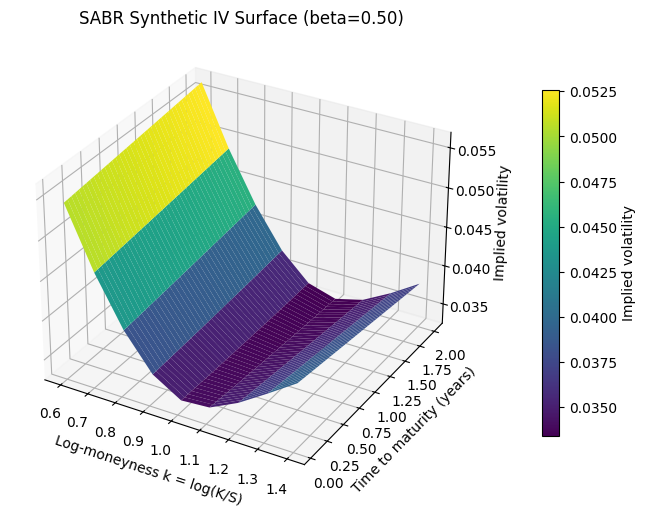

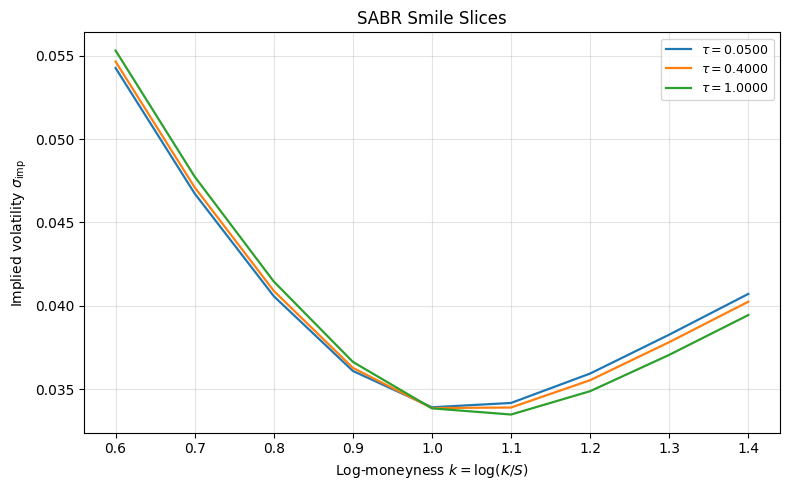

In [7]:
# Single synthetic parameter draw and one surface.
params = lhs_sabr_params(cfg, n_samples=1, seed=11)[0]
m, tau, iv = implied_vol_surface_for_params(params, cfg)

print("params (alpha, rho, nu):", np.round(params, 6))
print("surface shape:", iv.shape)

fig_surface = plot_sabr_surface(m, tau, iv, cfg=cfg)
fig_smiles = plot_sabr_smiles(m, tau, iv, smile_taus=np.array([0.05, 0.4, 1.0]))
plt.show()

In [8]:
# Batch synthetic surfaces for dataset prototyping.
params_batch, m_axis, tau_axis, iv_batch = implied_vol_surfaces_lhs(
    cfg,
    n_samples=4,
    n_batches=1,
    seed=7,
)

print("params_batch shape:", params_batch.shape)
print("iv_batch shape:", iv_batch.shape)
print("iv stats:", float(np.nanmin(iv_batch)), float(np.nanmean(iv_batch)), float(np.nanmax(iv_batch)))

params_batch shape: (4, 3)
iv_batch shape: (4, 9, 40)
iv stats: 0.00650565415294289 0.03255557126373287 0.08917319922319598
